In [101]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("IPL.csv")

print("Original Shape:", df.shape)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove rows with no match_id
df = df[df['match_id'].notna()]

# Fill numerical nulls
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(0)

# Fill categorical nulls
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

print("After Cleaning:", df.shape)

print(df.isnull().sum().sort_values(ascending=False).head())

/var/folders/t4/n3cs4cps2px2wrsc4x145nyh0000gp/T/ipykernel_60740/2675964122.py:5: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("IPL.csv")


Original Shape: (283678, 65)
After Cleaning: (283678, 65)
Unnamed: 0         0
player_of_match    0
win_outcome        0
toss_winner        0
toss_decision      0
dtype: int64


In [50]:
import pandas as pd
import numpy as np

df = pd.read_csv("IPL.csv", low_memory=False)

print(df.shape)

(283678, 65)


In [52]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

In [54]:
df.drop_duplicates(inplace=True)

In [56]:
df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce'
)

In [130]:
team_mapping = {

    'Delhi Daredevils':'Delhi Capitals',

    'Kings XI Punjab':'Punjab Kings',

    'Royal Challengers Bangalore':
    'Royal Challengers Bengaluru',

    'Rising Pune Supergiant':
    'Rising Pune Supergiants',
}


In [62]:
team_cols = [

    'batting_team',
    'bowling_team',
    'toss_winner',
    'match_won_by'

]

for col in team_cols:

    df[col] = (
        df[col]
        .replace(team_mapping)
    )

In [64]:
player_cols = [

    'batter',
    'bowler',
    'non_striker',
    'player_out',
    'player_of_match'

]

for col in player_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )

In [66]:
for col in player_cols:

    print(
        col,
        df[col].nunique()
    )

batter 719
bowler 564
non_striker 707
player_out 671
player_of_match 315


In [68]:
players = pd.Series(
    sorted(df['batter'].unique())
)

print(
    players[
        players.str.contains(
            "Dhoni",
            case=False,
            na=False
        )
    ]
)

400    MS Dhoni
dtype: object


In [70]:
player_mapping = {

    'M S Dhoni':'MS Dhoni'

}

In [72]:
for col in player_cols:

    df[col] = (
        df[col]
        .replace(player_mapping)
    )

In [76]:
df['is_wicket'] = (
    df['wicket_kind']
    .notna()
    .astype(int)
)

In [78]:
invalid_runs = df[
    (
        df['runs_batter']
        +
        df['runs_extras']
    )
    !=
    df['runs_total']
]

print(
    "Invalid rows:",
    len(invalid_runs)
)

Invalid rows: 0


In [80]:
invalid_over = df[
    (df['over'] < 1)
    |
    (df['over'] > 20)
]

print(len(invalid_over))

15138


In [82]:
print(
    df['innings']
    .value_counts()
)

innings
1    146997
2    136510
3        83
4        76
5         8
6         4
Name: count, dtype: int64


In [84]:
df['dot_ball'] = (
    df['runs_total']==0
).astype(int)

In [87]:
df['boundary'] = (
    df['runs_batter']
    .isin([4,6])
).astype(int)

In [89]:
df['boundary'] = (
    df['runs_batter']
    .isin([4,6])
).astype(int)

In [91]:
df['four'] = (
    df['runs_batter']==4
).astype(int)

In [93]:
df['six'] = (
    df['runs_batter']==6
).astype(int)

In [95]:
df['phase'] = 'Middle'

df.loc[
    df['over']<=6,
    'phase'
] = 'Powerplay'

df.loc[
    df['over']>=16,
    'phase'
] = 'Death'

In [97]:
matches = (
    df
    .drop_duplicates(
        subset='match_id'
    )
    .copy()
)

In [124]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

Unnamed: 0 : 283678
match_id : 1193
date : 905
match_type : 1
event_name : 1
innings : 6
batting_team : 19
bowling_team : 19
over : 20
ball : 7
ball_no : 123
batter : 719
bat_pos : 11
runs_batter : 7
balls_faced : 2
bowler : 564
valid_ball : 2
runs_extras : 7
runs_total : 8
runs_bowler : 8
runs_not_boundary : 2
extra_type : 9
non_striker : 707
non_striker_pos : 11
wicket_kind : 11
player_out : 671
fielders : 1120
runs_target : 177
review_batter : 211
team_reviewed : 14
review_decision : 3
umpire : 48
umpires_call : 2
player_of_match : 315
match_won_by : 20
win_outcome : 112
toss_winner : 19
toss_decision : 2
venue : 59
city : 38
day : 31
month : 7
year : 19
season : 23
gender : 1
team_type : 1
superover_winner : 8
result_type : 3
method : 2
balls_per_over : 1
overs : 1
event_match_no : 142
stage : 8
match_number : 1
team_runs : 283
team_balls : 122
team_wicket : 11
new_batter : 680
power_surge_start : 1
batter_runs : 158
batter_balls : 74
bowler_wicket : 2
batting_partners : 5235
next_

In [126]:
team_cols = [
    'batting_team',
    'bowling_team',
    'toss_winner',
    'match_won_by'
]

for col in team_cols:
    print("\n" + "="*50)
    print(col)
    print("="*50)

    print(sorted(df[col].dropna().unique()))


batting_team
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

bowling_team
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

toss_winner
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI

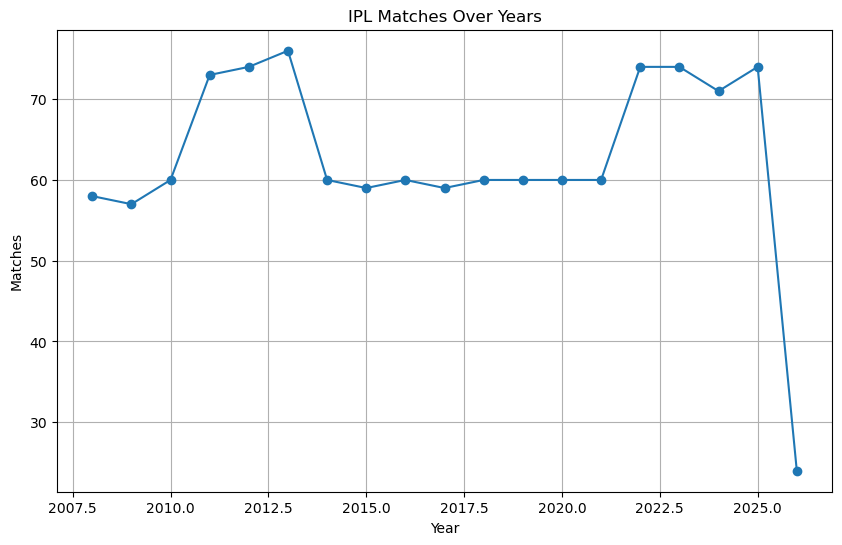

In [103]:
import matplotlib.pyplot as plt

matches_per_year = (
    matches.groupby('year')['match_id']
    .count()
)

plt.figure(figsize=(10,6))
matches_per_year.plot(marker='o')
plt.title("IPL Matches Over Years")
plt.ylabel("Matches")
plt.xlabel("Year")
plt.grid(True)
plt.show()

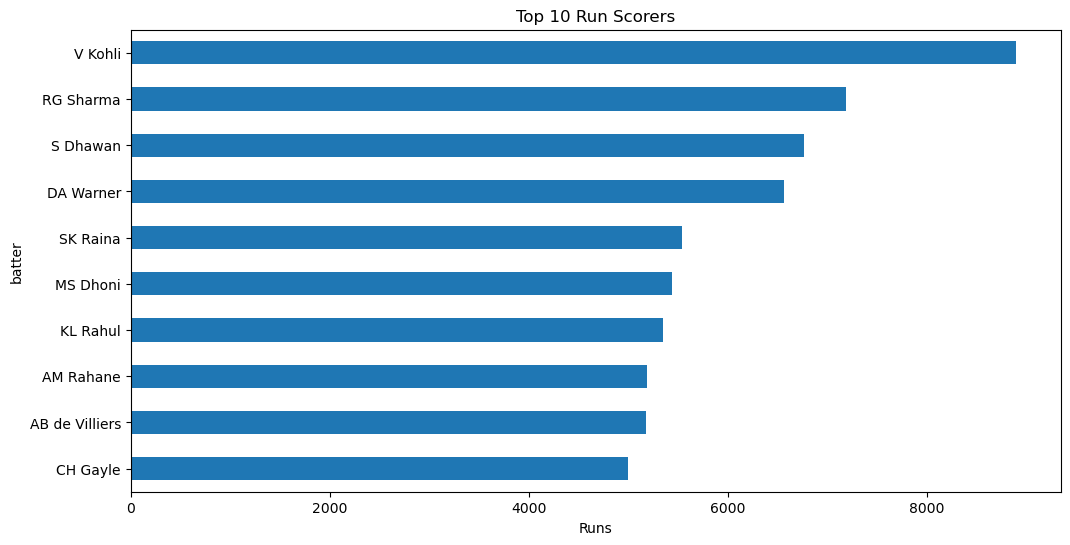

In [105]:
top_batters = (
    df.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_batters.sort_values().plot(kind='barh')

plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.show()

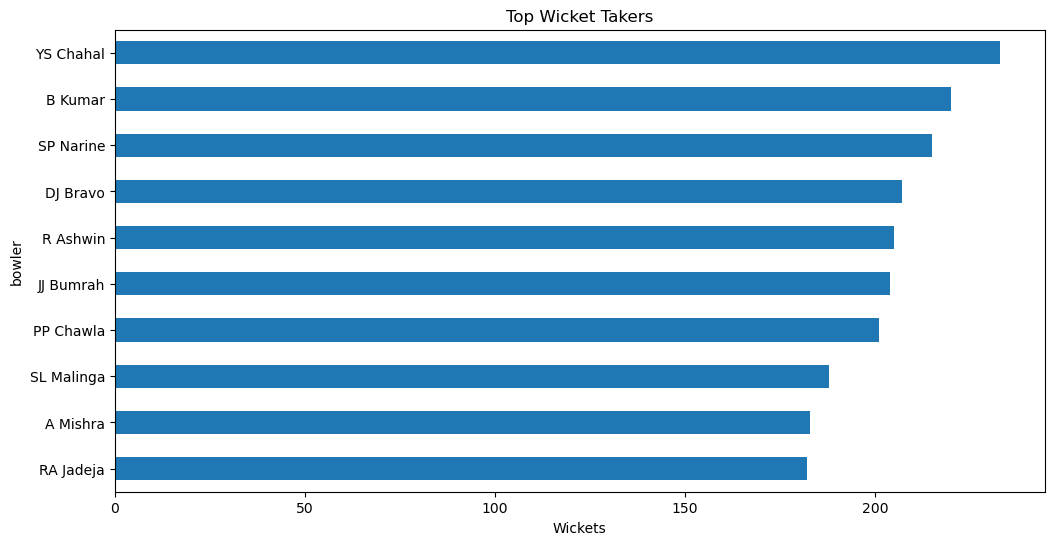

In [33]:
top_bowlers = (
    df[df['is_wicket']==1]
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_bowlers.sort_values().plot(kind='barh')

plt.title("Top Wicket Takers")
plt.xlabel("Wickets")
plt.show()

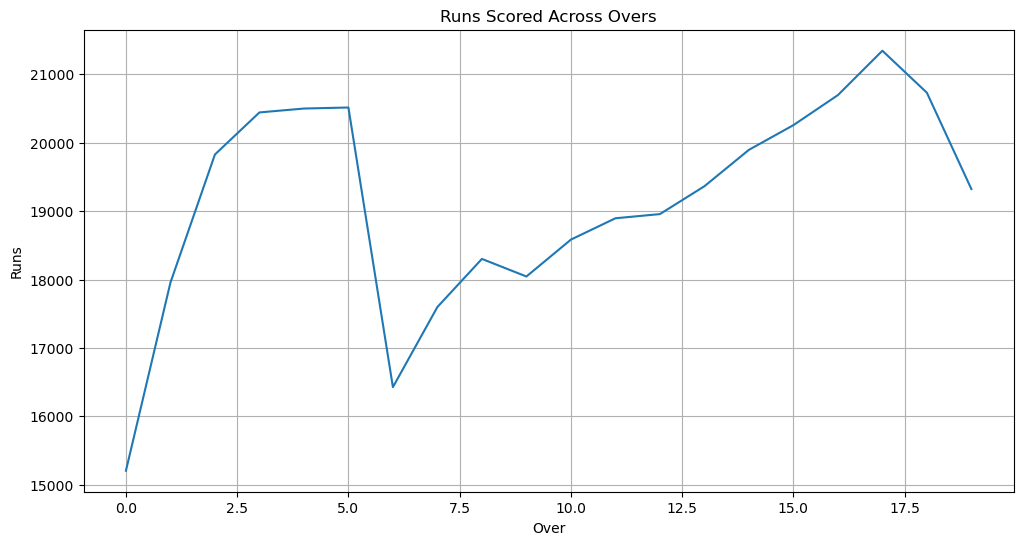

In [107]:
runs_over = (
    df.groupby('over')['runs_total']
    .sum()
)

plt.figure(figsize=(12,6))
runs_over.plot()

plt.title("Runs Scored Across Overs")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.grid(True)
plt.show()

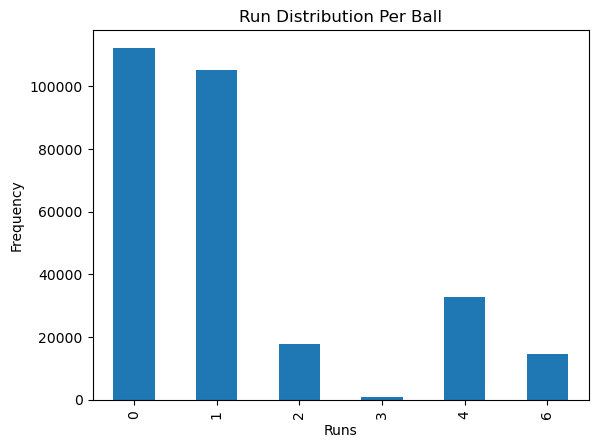

In [109]:
boundary_counts = df['runs_batter'].value_counts()

boundary_counts = boundary_counts[
    boundary_counts.index.isin([0,1,2,3,4,6])
]

boundary_counts.sort_index().plot(
    kind='bar'
)

plt.title("Run Distribution Per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

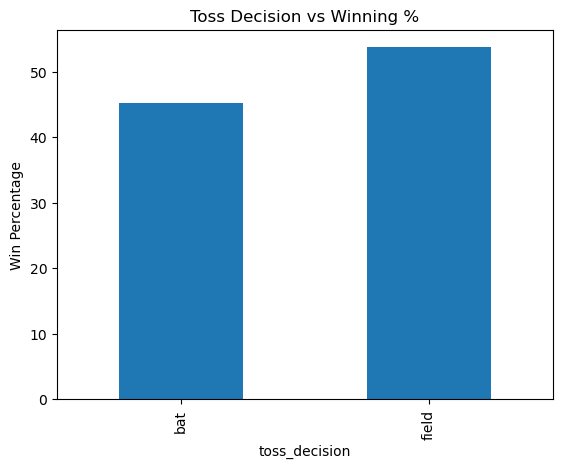

In [111]:
matches['won_toss_match'] = np.where(
    matches['toss_winner']==matches['match_won_by'],
    1,
    0
)

impact = matches.groupby(
    'toss_decision'
)['won_toss_match'].mean()*100

impact.plot(kind='bar')

plt.title("Toss Decision vs Winning %")
plt.ylabel("Win Percentage")
plt.show()

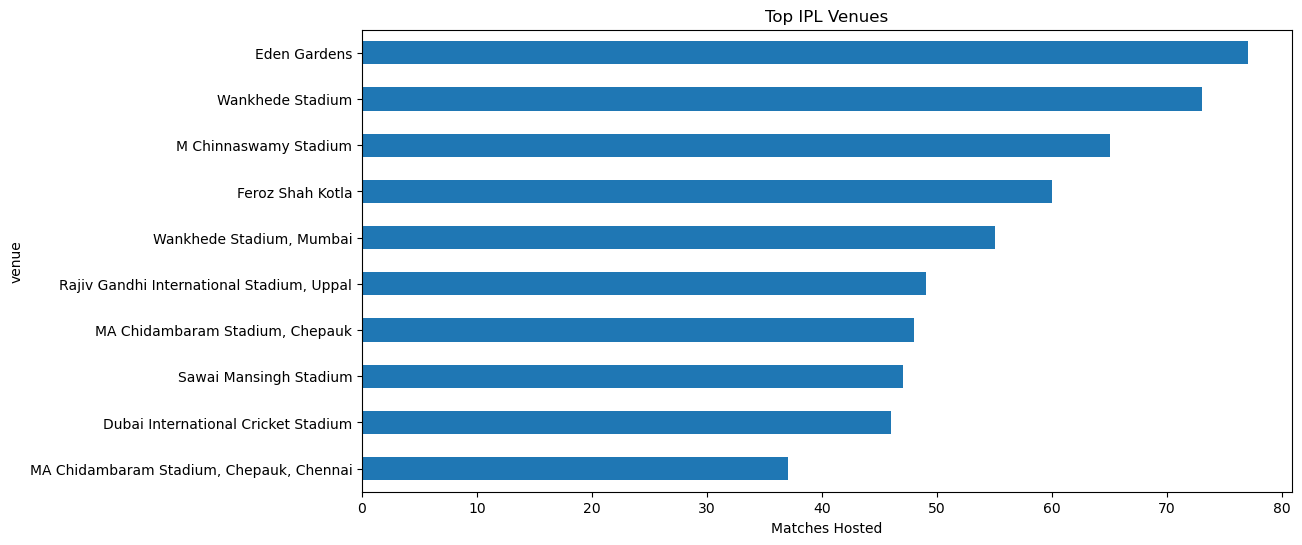

In [113]:
top_venues = (
    matches.groupby('venue')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_venues.sort_values().plot(kind='barh')

plt.title("Top IPL Venues")
plt.xlabel("Matches Hosted")
plt.show()

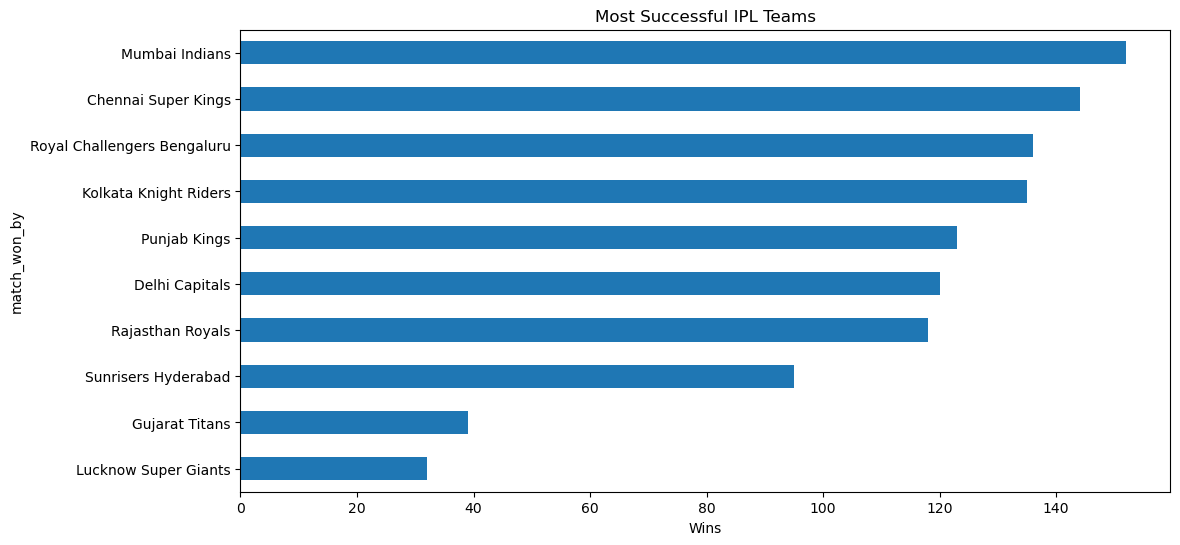

In [115]:
team_wins = (
    matches['match_won_by']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))
team_wins.sort_values().plot(kind='barh')

plt.title("Most Successful IPL Teams")
plt.xlabel("Wins")
plt.show()